In [ ]:
# youtube - https://www.youtube.com/watch?v=zCEJurLGFRk&t=14s
# % pip install google-api-python-client google-auth-httplib2 google-auth-oauthlib gspread
import gspread
from google.oauth2.service_account import Credentials
import pandas as pd
from gspread_dataframe import set_with_dataframe

from data import Data
from cache_pandas import timed_lru_cache
import logging

@timed_lru_cache(seconds=None, maxsize=None)
def dataF():
    logging.info("Fetching data in dataF()")
    df = Data()
    vix_data = df.vix_history()
    policy_rate1, policy_rate2, policy_rate3 = df.policy_rate()
    fx = df.forex_exchange()
    cds = df.cds()
    liquidity = df.liquidity()
    gdp_growth = df.gdp_growth()
    logging.info("Completed fetching data in dataF()")
    return (
        vix_data, #use this
        policy_rate1, #use this
        policy_rate2,
        policy_rate3,
        fx, #use this
        cds, #use this
        liquidity, #use this
        gdp_growth, #use this
    )


vix2, policy_rate12, policy_rate22, policy_rate32, fx2, cds2, liquidity2, gdp_growth2, = dataF()

scopes = [
    'https://www.googleapis.com/auth/spreadsheets']

creds = Credentials.from_service_account_file(
    'credential.json', scopes=scopes)

client = gspread.authorize(creds)

# 1PP6gpBcoOHjjgCx7LuHLa3dv4ET6ufKvpSY4UDvBczQ
sheet_id = '11Ora6_5EoQJdgnUpjjZgFZyrILguo1c32mde_uQwupw'
sheet = client.open_by_key(sheet_id)

df = pd.DataFrame({
    "Name": ["Alice", "Bob", "Charlie"],
    "Age": [25, 30, 40]
})

set_with_dataframe(sheet.sheet1, df) 

values_list = sheet.sheet1.get_all_values()
print(values_list)

worksheet_list = map(lambda x: x.title, sheet.worksheets())
worksheet_name = {'vix_data': vix_data, 'policy_rate1': policy_rate1, 'fx': fx, 'cds': cds, 'liquidity': liquidity, 'gdp_growth': gdp_growth}
for new_worksheet_name, data in worksheet_name.items():
    if new_worksheet_name in worksheet_list:
        sheet1 = sheet.worksheet(new_worksheet_name)
    else:
        sheet1 = sheet.add_worksheet(title=new_worksheet_name, rows=10, cols=10)
    set_with_dataframe(sheet1, data)

# sheet.worksheet(new_worksheet_name) -- to select worksheet page
# sheet.add_worksheet(new_worksheet_name, rows=10, cols=10) -- add new worksheet page

c:\Users\AhmadAizudeen\OneDrive - The SOUTH-EAST ASIAN CENTRAL BANKS (SEACEN) RESEARCH AND TRAINING\Desktop\NLP Project\cfm-nlp\data.py:161: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"]) + pd.offsets.MonthEnd(0)
c:\Users\AhmadAizudeen\OneDrive - The SOUTH-EAST ASIAN CENTRAL BANKS (SEACEN) RESEARCH AND TRAINING\Desktop\NLP Project\cfm-nlp\data.py:296: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df2["Date"] = pd.to_datetime(df2["Date"]) + pd.offsets.MonthEnd(0)
c:\USERS\AHMADAIZUDEEN\ONEDRIVE - THE SOUTH-EAST ASIAN CENTRAL BANKS (SEACEN) RESEARCH AND TRAINING\DESKTOP\NLP PROJECT\VENC\Lib\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a p

[['Name', 'Age'], ['Alice', '25'], ['Bob', '30'], ['Charlie', '40']]


In [ ]:
# 
# Loop through worksheet names and data
for new_worksheet_name, data in worksheet_name.items():
    if new_worksheet_name in worksheet_list:
        sheet = spreadsheet.worksheet(new_worksheet_name)  # Select existing worksheet
    else:
        sheet = spreadsheet.add_worksheet(title=new_worksheet_name, rows=10, cols=10)  # ✅ Use 'spreadsheet' object
    
    # Upload DataFrame to Google Sheets
    set_with_dataframe(sheet, data)

print("All data uploaded successfully!")

AttributeError: 'Worksheet' object has no attribute 'add_worksheet'

In [124]:
import pandas as pd 

yield_data1 = pd.read_excel(r"C:\Users\AhmadAizudeen\OneDrive - The SOUTH-EAST ASIAN CENTRAL BANKS (SEACEN) RESEARCH AND TRAINING\Roger and Aizudeen\00 dlx.xlsx", header=1)
yield_data1 = yield_data1[[*yield_data1.columns[[0,1,3]]]]
yield_data1.drop([0,1,2], inplace=True)
yield_data1.rename(columns={'.DESC': 'Date',
                          'Indonesia: 10 Year Treasury Bond Mid Yield (% p.a.)': 'Indonesia',
                          'Philippines: 10 Year Treasury Bond Mid Yield (% p.a.)': 'Philippines'},
                    inplace=True)

# yield_data1["Date"] = pd.to_datetime(yield_data1["Date"], errors='coerce') + pd.offsets.MonthEnd(0)
yield_data1['Month'] = yield_data1['Date'].apply(lambda x: x[:3])
yield_data1['Year'] = yield_data1['Date'].apply(lambda x: x[-2:])
yield_data1["Date"] = yield_data1.apply(lambda x: pd.to_datetime(f"{x['Month']} {x['Year']}", format='%b %y') + pd.offsets.MonthEnd(0), axis=1)
yield_data1.drop(['Month', 'Year'], axis=1, inplace=True)
yield_data2 = pd.read_excel(r"C:\Users\AhmadAizudeen\OneDrive - The SOUTH-EAST ASIAN CENTRAL BANKS (SEACEN) RESEARCH AND TRAINING\Capital Flow Monitor\SEACEN CFM January 2025\edited files\Data\Financial Stress Indices.xlsx"
                            , sheet_name='Yields2'
                            , header=1)
yield_data2=yield_data2[yield_data2.columns[:11]]
yield_data2.drop([0,1], inplace=True)
yield_data2.rename(columns={'Region': 'Date'}, inplace=True)
yield_data2["Date"] = pd.to_datetime(yield_data2["Date"]) + pd.offsets.MonthEnd(0)
yield_data2.drop('Philippines', axis=1, inplace=True)

yield_data = yield_data2.join(yield_data1.set_index('Date'), on='Date')
yield_data.set_index('Date', inplace=True)

yield_data_calc = yield_data.apply(lambda x : x - x['United States'], axis =1)
yield_data_calc.drop('United States', axis=1, inplace=True)
yield_data_calc = yield_data_calc.loc[yield_data_calc.index >= "2010-01-31"]
yield_data_calc['Asia'] = yield_data_calc.mean(axis= 1)
yield_data_calc = (yield_data_calc - yield_data_calc.mean()) / yield_data_calc.std()
yield_data_calc

,Thailand,Taiwan,Singapore,South Korea,Malaysia,India,Hong Kong SAR (China),China,Indonesia,Philippines,Asia
Date,,,,,,,,,,,
2010-01-31,0.175651,-1.158241,-1.901368,1.572966,-1.004538,-1.107842,-1.050142,-0.741576,NaN,NaN,-1.540744
2010-02-28,0.087742,-1.236897,-1.485320,1.555688,-0.980961,-0.798749,-1.246005,-0.869708,NaN,NaN,-1.505457
2010-03-31,0.046732,-1.259095,-1.260817,1.023806,-1.166129,-0.865235,-1.426455,-0.900146,NaN,NaN,-1.638070
2010-04-30,-0.370188,-1.407762,-1.865981,0.854675,-1.463067,-1.028513,-1.546308,-1.064175,NaN,NaN,-1.940724
2010-05-31,-0.012640,-0.936574,-0.681719,1.458693,-0.888538,-0.862325,-1.134185,-0.777569,NaN,NaN,-1.390754
...,...,...,...,...,...,...,...,...,...,...,...
2024-07-31,-2.132792,-1.681953,-2.281407,-1.879522,-2.484187,-2.197072,-2.174949,-2.542791,-1.683475,-0.423165,-2.454110
2024-08-31,-1.785504,-1.277460,-1.831526,-1.619181,-1.911162,-1.901352,-1.637959,-2.191315,-1.594144,-0.228112,-2.039476
2024-09-30,-1.675572,-1.240222,-1.707193,-1.427541,-1.779653,-1.885661,-1.585829,-2.078945,-1.606654,-0.250560,-1.949901


In [ ]:
import pandas as pd
import numpy as np

key_dict = {
    'Select this link and click Refresh/Edit Download to update data and add or remove series': 'Date',
    'Index: Shenzhen Stock Exchange: Composite': 'China',
    'Equity Market Index: Month End: Hang Seng': 'Hong Kong SAR (China)',
    'Equity Market Index: Month End: BSE: Sensitive 30 (Sensex)': 'India',
    'Equity Market Index: Month End: Jakarta Composite': 'Indonesia',
    'Equity Market Index: Month End: FTSE Bursa Malaysia: Composite': 'Malaysia',
    'Equity Market Index: Month End: PSEi': 'Philippines',
    'Equity Market Index: Month End: FTSE Strait Times': 'Singapore',
    'Equity Market Index: Month End: KOSPI': 'South Korea',
    'TWSE: Equity Market Index: TAIEX Capitalization Weighted: Month Avg': 'Taiwan',
    'Equity Market Index: Month End: SET': 'Thailand',
}


stock_data = pd.read_excel(r'C:\Users\Admin\OneDrive\Desktop\data science project\cfm-nlp\cfm-nlp\Financial Stress Indices.xlsx', sheet_name='Stock Price Indexes')
stock_data = stock_data[key_dict.keys()]
stock_data.drop([0,1,2], inplace=True)
stock_data.rename(columns=key_dict, inplace=True)
stock_data2 = stock_data.copy()
stock_data2["Date"] = pd.to_datetime(stock_data2["Date"]) + pd.offsets.MonthEnd(0)
stock_data2.set_index('Date', inplace=True)
stock_data2 = stock_data2.loc[stock_data2.index >= "2009-01-01"]
stock_data2 = stock_data2.astype(float)

stock_data_calc = stock_data2.apply(lambda x : np.log(x))
stock_data_calc = (stock_data_calc.shift(1) - stock_data_calc) * 100 ## can use pandas .diff() function
stock_data_calc['Asia'] = stock_data_calc.mean(axis=1)
stock_data_calc = stock_data_calc.loc[stock_data_calc.index >= "2010-01-01"]
stock_data_calc = (stock_data_calc - stock_data_calc.mean())/stock_data_calc.std()
stock_data_calc

,China,Hong Kong SAR (China),India,Indonesia,Malaysia,Philippines,Singapore,South Korea,Taiwan,Thailand,Asia
Date,,,,,,,,,,,
2010-01-31,0.985631,1.429724,1.552245,-0.598928,0.411379,0.774487,1.382779,1.109915,-0.729120,1.270314,1.194631
2010-02-28,-0.575225,-0.424380,0.086492,0.742925,-0.271396,-0.535273,-0.014485,0.152743,2.491955,-0.699817,0.000402
2010-03-31,-0.403999,-0.532226,-1.179834,-2.000632,-1.272603,-0.697535,-1.173968,-1.254744,-1.062781,-1.891677,-1.515336
2010-04-30,1.191524,0.095233,0.141128,-1.543941,-0.619549,-0.733150,-0.706569,-0.571045,-0.787946,0.788312,-0.194366
2010-05-31,1.041462,1.124629,0.925268,1.655979,1.640164,0.198716,1.971419,1.336176,1.996414,0.469338,1.663341
...,...,...,...,...,...,...,...,...,...,...,...
2024-07-31,0.100592,0.357129,-0.529081,-0.527123,-0.712385,-0.568283,-0.869939,0.257865,-0.776042,-0.256413,-0.395732
2024-08-31,0.612060,-0.641776,0.018428,-1.246655,-1.059951,-0.762792,0.129685,0.815971,1.831668,-0.554602,-0.071503
2024-09-30,-2.970088,-2.794832,-0.308957,0.614162,0.658069,-1.005747,-0.975629,0.715202,0.113918,-1.346927,-1.411999


In [50]:
# China	Hong Kong SAR (China)	India	Indonesia	Malaysia	Philippines	Singapore	South Korea	Taiwan	Thailand

country_list = ['Region', 'China', 'Hong Kong SAR (China)', 'India', 'Indonesia', 'Malaysia', 'Philippines', 'Singapore', 'South Korea', 'Taiwan', 'Thailand']
fx = pd.read_excel(r'C:\Users\Admin\OneDrive\Desktop\data science project\cfm-nlp\cfm-nlp\Financial Stress Indices.xlsx', sheet_name='FX', header=1)
fx.drop([0,1], inplace=True)
fx = fx[country_list]
fx.rename(columns={'Region': 'Date'}, inplace=True)
fx["Date"] = pd.to_datetime(fx["Date"]) + pd.offsets.MonthEnd(0) 
fx.set_index('Date', inplace=True) 
fx = fx.loc[fx.index >= "2009-12-31"]
fx = fx.astype(float)
fx = ((fx / fx.shift(1))-1) * 100
fx['Asia'] = fx.mean(axis=1)
fx = (fx - fx.mean())/fx.std()

ora = pd.read_excel(r'C:\Users\Admin\OneDrive\Desktop\data science project\cfm-nlp\cfm-nlp\Financial Stress Indices.xlsx', sheet_name='ORA', header=1)
ora.drop([0,1], inplace=True)
ora = ora[country_list]
ora.rename(columns={'Region': 'Date'}, inplace=True)
ora["Date"] = pd.to_datetime(ora["Date"]) + pd.offsets.MonthEnd(0)
ora.set_index('Date', inplace=True)
ora = ora.loc[ora.index >= "2009-12-31"]
ora = ora.astype(float)
ora = ora/1000
ora = ((ora.shift(1) / ora)-1) * 100
ora['Asia'] = ora.mean(axis=1)
ora = (ora - ora.mean())/ora.std()


empi = fx - ora
empi

,China,Hong Kong SAR (China),India,Indonesia,Malaysia,Philippines,Singapore,South Korea,Taiwan,Thailand,Asia
Date,,,,,,,,,,,
2009-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-31,0.345952,1.054376,-1.222844,1.503236,-0.576233,0.767593,0.259894,-0.245190,-0.443412,0.880671,0.240604
2010-02-28,0.141868,0.614923,-1.090945,-0.310978,0.488664,0.164352,0.537979,-0.474865,1.017381,-0.142971,-0.016566
2010-03-31,0.552546,-0.614600,-1.371011,-0.122339,-2.360757,-2.002335,1.003273,-0.574068,-0.071055,-0.558462,-0.914192
2010-04-30,1.206054,-0.020688,-1.127284,2.507447,-1.729082,-1.064146,-0.033373,1.018722,-0.401503,0.544436,0.193751
...,...,...,...,...,...,...,...,...,...,...,...
2024-07-31,0.755658,0.216318,1.329120,0.815858,-0.077479,-0.031528,0.317043,0.104054,-0.095159,0.395229,0.691954
2024-08-31,0.322714,-0.749756,0.422593,-1.428077,-2.242463,-1.512296,-1.513595,-0.905395,0.404154,-1.751240,-1.355650
2024-09-30,-0.805028,-0.818792,1.345380,-1.195530,-1.016961,0.190530,-0.868812,-0.061582,-1.571829,-1.265495,-0.738986


In [64]:
from arch import arch_model

model = arch_model(stock_data_calc['China'], vol="Garch", p=2, q=2)

# Fit the model to estimate parameters
results = model.fit()

# Print summary
results.conditional_volatility


Iteration:      1,   Func. Count:      8,   Neg. LLF: 528.6378468914753
Iteration:      2,   Func. Count:     17,   Neg. LLF: 8127.915674539056
Iteration:      3,   Func. Count:     26,   Neg. LLF: 260.1762390457921
Iteration:      4,   Func. Count:     35,   Neg. LLF: 253.8855436075869
Iteration:      5,   Func. Count:     43,   Neg. LLF: 246.3693381776859
Iteration:      6,   Func. Count:     51,   Neg. LLF: 246.6772313953081
Iteration:      7,   Func. Count:     59,   Neg. LLF: 245.84695229558207
Iteration:      8,   Func. Count:     66,   Neg. LLF: 245.78716004487268
Iteration:      9,   Func. Count:     73,   Neg. LLF: 245.76660556965916
Iteration:     10,   Func. Count:     80,   Neg. LLF: 245.7647836282989
Iteration:     11,   Func. Count:     87,   Neg. LLF: 245.76454502000385
Iteration:     12,   Func. Count:     94,   Neg. LLF: 245.76454061548566
Iteration:     13,   Func. Count:    101,   Neg. LLF: 245.7645385477081
Iteration:     14,   Func. Count:    107,   Neg. LLF: 245.7

Date
2010-01-31    0.996301
2010-02-28    0.995122
2010-03-31    0.956568
2010-04-30    0.898855
2010-05-31    0.935395
                ...   
2024-07-31    0.900664
2024-08-31    0.872190
2024-09-30    0.844204
2024-10-31    1.312549
2024-11-30    1.373401
Name: cond_vol, Length: 179, dtype: float64

Best GARCH Settings: p=2, q=2


c:\Users\Admin\OneDrive\Desktop\data science project\cfm-nlp\venv\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.01153. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
c:\Users\Admin\OneDrive\Desktop\data science project\cfm-nlp\venv\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.01153. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


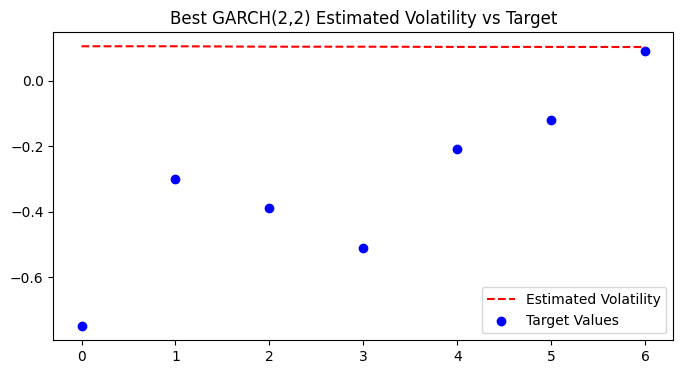

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

# Given Standardized MoM Change Ln Stock Price data
data = np.array([0.6810, 0.6116, 0.8439, 0.7964, 0.7331, 0.8898, 0.9352])

# Fit different GARCH models and compare results
best_model = None
best_diff = float("inf")

for p in range(1, 3):  # Try p = 1, 2
    for q in range(1, 3):  # Try q = 1, 2
        model = arch_model(data, vol="Garch", p=p, q=q, dist="normal")  # Normal distribution
        results = model.fit(disp="off")

        # Extract conditional volatility
        conditional_volatility = results.conditional_volatility

        # Target values to match
        target_values = np.array([-0.75, -0.30, -0.39, -0.51, -0.21, -0.12, 0.09])

        # Compute the difference between model output and target
        diff = np.sum(np.abs(conditional_volatility - target_values))

        # Keep track of best model
        if diff < best_diff:
            best_diff = diff
            best_model = (p, q, conditional_volatility)

# Print best GARCH settings
best_p, best_q, best_volatility = best_model
print(f"Best GARCH Settings: p={best_p}, q={best_q}")

# Plot the best volatility estimate
plt.figure(figsize=(8, 4))
plt.plot(best_volatility, label="Estimated Volatility", color="red", linestyle="--")
plt.scatter(range(len(target_values)), target_values, label="Target Values", color="blue")
plt.title(f"Best GARCH({best_p},{best_q}) Estimated Volatility vs Target")
plt.legend()
plt.show()


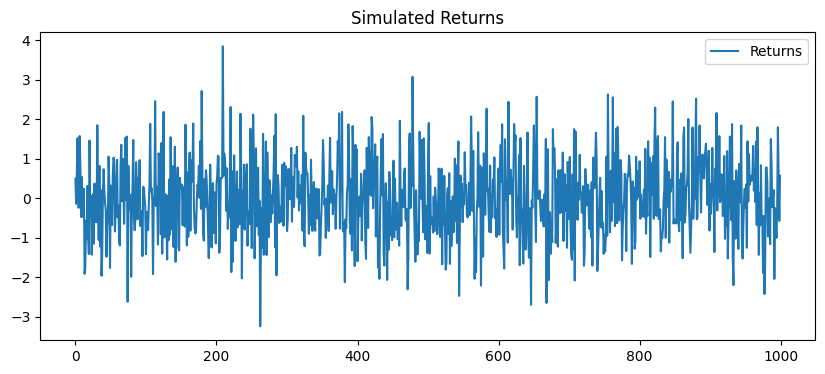

Iteration:      1,   Func. Count:      6,   Neg. LLF: 4488.113750684418
Iteration:      2,   Func. Count:     15,   Neg. LLF: 1441.6532640080381
Iteration:      3,   Func. Count:     22,   Neg. LLF: 1397.4377335583126
Iteration:      4,   Func. Count:     27,   Neg. LLF: 1397.4267922813399
Iteration:      5,   Func. Count:     32,   Neg. LLF: 1511.0981687294732
Iteration:      6,   Func. Count:     38,   Neg. LLF: 1510.3165787045446
Iteration:      7,   Func. Count:     44,   Neg. LLF: 1504.1226252673584
Iteration:      8,   Func. Count:     50,   Neg. LLF: 1417.4101255529754
Iteration:      9,   Func. Count:     56,   Neg. LLF: 1397.7880948636684
Iteration:     10,   Func. Count:     62,   Neg. LLF: 60252.36911013471
Iteration:     11,   Func. Count:     72,   Neg. LLF: 549395697.0008721
Iteration:     12,   Func. Count:     80,   Neg. LLF: 1398.105292657417
Iteration:     13,   Func. Count:     87,   Neg. LLF: 1471.720128879787
Iteration:     14,   Func. Count:     93,   Neg. LLF: 14

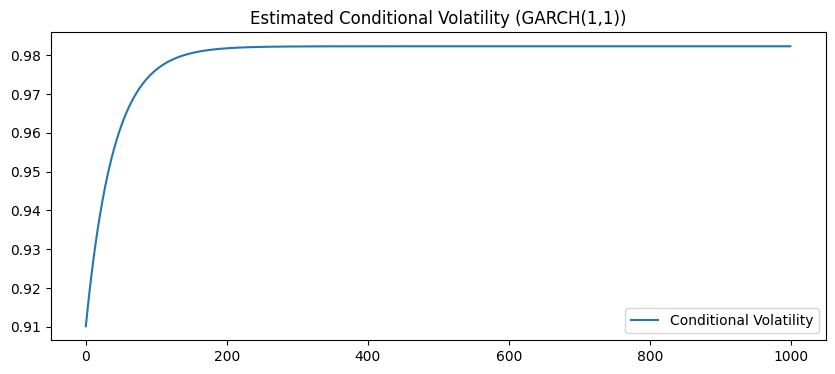

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

# Generate synthetic returns data (or load real financial data)
np.random.seed(42)
returns = np.random.normal(0, 1, 1000)  # Simulated daily returns

# Convert to a Pandas Series
returns = pd.Series(returns)

# Plot the returns
plt.figure(figsize=(10, 4))
plt.plot(returns, label="Returns")
plt.title("Simulated Returns")
plt.legend()
plt.show()

# Fit a GARCH(1,1) model
model = arch_model(returns, vol="Garch", p=1, q=1)

# Fit the model to estimate parameters
results = model.fit()

# Print summary
print(results.summary())

# Plot volatility (conditional standard deviation)
plt.figure(figsize=(10, 4))
plt.plot(results.conditional_volatility, label="Conditional Volatility")
plt.title("Estimated Conditional Volatility (GARCH(1,1))")
plt.legend()
plt.show()

In [55]:
returns


0      0.496714
1     -0.138264
2      0.647689
3      1.523030
4     -0.234153
         ...   
995   -0.281100
996    1.797687
997    0.640843
998   -0.571179
999    0.572583
Name: None, Length: 1000, dtype: float64

In [39]:
list1

['https://www.seacen.org/publication-working.php?pid=702001-100492',
 'https://www.seacen.org/publication-working.php?pid=702001-100483',
 'https://www.seacen.org/publication-working.php?pid=702001-100482',
 'https://www.seacen.org/publication-working.php?pid=702001-100480',
 'https://www.seacen.org/publication-working.php?pid=702001-100471',
 'https://www.seacen.org/publication-working.php?pid=702001-100461',
 'https://www.seacen.org/publication-working.php?pid=702001-100449',
 'https://www.seacen.org/publication-working.php?pid=702001-100444',
 'https://www.seacen.org/publication-working.php?pid=702001-0',
 'https://www.seacen.org/publication-working.php?pid=702001-100430',
 'https://www.seacen.org/publication-working.php?pid=702001-100427',
 'https://www.seacen.org/publication-working.php?pid=702001-100417',
 'https://www.seacen.org/publication-working.php?pid=702001-100413',
 'https://www.seacen.org/publication-working.php?pid=702001-100402',
 'https://www.seacen.org/publication-wo

In [40]:
import requests as r
for x in list1:
    response = r.get(x)
    print(response.status_code)

200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200
200


In [1]:
import pandas as pd 

df = pd.read_excel(r'C:\Users\Admin\OneDrive\Desktop\data science project\cfm-nlp\cfm-nlp\OE Inflation_February 2025.xlsx', sheet_name='Default (2)')
df

,country,quarter,inflation2000,inflation2001,inflation2002,inflation2003,inflation2004,inflation2005,inflation2006,inflation2007,...,inflation2013,inflation2014,inflation2015,inflation2016,inflation2017,inflation2018,inflation2019,inflation2020,inflation2021,inflation2022
0,Albania,Q1,4.20,3.53,2.10,2.87,2.16,2.05,2.55,2.99,...,1.85,0.66,1.96,2.18,1.80,1.80,1.15,1.05,3.72,7.40
1,Albania,Q2,4.20,3.53,2.10,2.87,2.16,2.05,2.55,2.99,...,1.85,0.66,1.96,2.18,1.80,1.80,1.15,1.05,3.72,7.40
2,Albania,Q3,4.20,3.53,2.10,2.87,2.16,2.05,2.55,2.99,...,1.85,0.66,1.96,2.18,1.80,1.80,1.15,1.05,3.72,7.40
3,Albania,Q4,4.20,3.53,2.10,2.87,2.16,2.05,2.55,2.99,...,1.85,0.66,1.96,2.18,1.80,1.80,1.15,1.05,3.72,7.40
4,Algeria,Q1,1.66,0.83,4.42,-1.05,6.43,4.53,-0.88,3.11,...,5.28,2.30,5.54,4.70,7.21,1.95,3.58,2.40,4.86,9.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547,Vietnam,Q4,NaN,NaN,4.04,3.03,9.68,8.68,6.58,12.62,...,6.03,1.84,0.60,4.72,2.59,2.99,5.24,0.18,1.81,4.54
548,Zambia,Q1,23.47,28.77,18.24,22.75,17.90,17.93,10.99,12.71,...,6.55,7.56,7.06,22.12,6.60,7.16,7.63,14.12,22.80,13.03
549,Zambia,Q2,24.57,20.43,23.43,21.76,18.35,18.97,8.31,11.01,...,7.33,7.95,7.07,20.98,6.64,7.17,8.33,15.64,24.43,9.72
550,Zambia,Q3,27.73,17.54,23.76,20.68,17.41,18.97,8.00,9.18,...,7.20,8.14,8.01,18.98,6.55,7.88,10.45,15.74,22.17,9.95


In [21]:
df2 = df.copy()

df2['index'] = df2['country'] + ' ' + df2['quarter']
df2.drop(['country', 'quarter'], axis=1, inplace=True)
df2
# df.melt(id_vars=['index'], var_name='Date', value_name='Inflation Rate')

,inflation2000,inflation2001,inflation2002,inflation2003,inflation2004,inflation2005,inflation2006,inflation2007,inflation2008,inflation2009,...,inflation2014,inflation2015,inflation2016,inflation2017,inflation2018,inflation2019,inflation2020,inflation2021,inflation2022,index
0,4.20,3.53,2.10,2.87,2.16,2.05,2.55,2.99,2.06,3.54,...,0.66,1.96,2.18,1.80,1.80,1.15,1.05,3.72,7.40,Albania Q1
1,4.20,3.53,2.10,2.87,2.16,2.05,2.55,2.99,2.06,3.54,...,0.66,1.96,2.18,1.80,1.80,1.15,1.05,3.72,7.40,Albania Q2
2,4.20,3.53,2.10,2.87,2.16,2.05,2.55,2.99,2.06,3.54,...,0.66,1.96,2.18,1.80,1.80,1.15,1.05,3.72,7.40,Albania Q3
3,4.20,3.53,2.10,2.87,2.16,2.05,2.55,2.99,2.06,3.54,...,0.66,1.96,2.18,1.80,1.80,1.15,1.05,3.72,7.40,Albania Q4
4,1.66,0.83,4.42,-1.05,6.43,4.53,-0.88,3.11,5.42,9.39,...,2.30,5.54,4.70,7.21,1.95,3.58,2.40,4.86,9.62,Algeria Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547,NaN,NaN,4.04,3.03,9.68,8.68,6.58,12.62,19.90,6.51,...,1.84,0.60,4.72,2.59,2.99,5.24,0.18,1.81,4.54,Vietnam Q4
548,23.47,28.77,18.24,22.75,17.90,17.93,10.99,12.71,9.92,13.34,...,7.56,7.06,22.12,6.60,7.16,7.63,14.12,22.80,13.03,Zambia Q1
549,24.57,20.43,23.43,21.76,18.35,18.97,8.31,11.01,11.97,14.31,...,7.95,7.07,20.98,6.64,7.17,8.33,15.64,24.43,9.72,Zambia Q2
550,27.73,17.54,23.76,20.68,17.41,18.97,8.00,9.18,14.12,12.73,...,8.14,8.01,18.98,6.55,7.88,10.45,15.74,22.17,9.95,Zambia Q3


In [ ]:
# df3 = df2['index']+df2[df2.columns[:23]]
# df3 = pd.concat([df2['index'], df2[df2.columns[:23]]], axis=1)
# df3
df3 = df2.melt(id_vars=['index'], var_name='Date', value_name='Inflation Rate')
df3['country'] = df3['index'].apply(lambda x: x.split()[0])
df3['quarter'] = df3['index'].apply(lambda x: x.split()[1])
df3.drop('index', axis=1, inplace=True)
# df3[['country', 'quarter', 'Date', 'Inflation Rate']].to_excel('output.xlsx', index=False)

In [32]:
df3.sort_values(['country', 'quarter', 'Date'], inplace=True)
df3.reset_index(drop=True, inplace=True)
df3

,Date,Inflation Rate,country,quarter
0,inflation2000,4.20,Albania,Q1
1,inflation2001,3.53,Albania,Q1
2,inflation2002,2.10,Albania,Q1
3,inflation2003,2.87,Albania,Q1
4,inflation2004,2.16,Albania,Q1
...,...,...,...,...
12691,inflation2018,5.22,eSwatini,Q4
12692,inflation2019,2.00,eSwatini,Q4
12693,inflation2020,4.60,eSwatini,Q4
12694,inflation2021,3.50,eSwatini,Q4


In [34]:
df3[['country', 'quarter', 'Date', 'Inflation Rate']].to_excel('output.xlsx', index=False)